# Forbes — Retrained with Multi-Model MD Objective

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q opencv-python-headless scipy scikit-image easydict einops timm tqdm facenet-pytorch insightface onnxruntime-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 18.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 136.5 MB/s eta 0:00:00


In [ ]:
!pip install -q wandb

### **Imports**

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
import kagglehub
import wandb
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import (
    Dropout, MaxPool2d, Sequential, Conv2d, Linear,
    BatchNorm1d, BatchNorm2d, PReLU, Sigmoid, Module
)
import torch.utils.data as data
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import namedtuple
from facenet_pytorch import InceptionResnetV1
from insightface.model_zoo import model_zoo

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
if device == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'CUDA   : {torch.version.cuda}')

Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Server Edition
CUDA   : 12.8


In [ ]:
# Set your Kaggle credentials
KAGGLE_USERNAME = 'tchisenga'
KAGGLE_KEY      = '07a36ac2d1bf66e69e3d6a15277c5603'

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY']      = KAGGLE_KEY

In [ ]:
celeba_path = kagglehub.dataset_download('jessicali9530/celeba-dataset')
print(f'CelebA downloaded to: {celeba_path}')

# Find the actual image folder
CELEBA_DIR = os.path.join(celeba_path, 'img_align_celeba', 'img_align_celeba')
print(f'Image folder: {CELEBA_DIR}')
print(f'Sample files: {os.listdir(CELEBA_DIR)[:3]}')

100%|██████████| 1.33G/1.33G [00:33<00:00, 42.2MB/s]

Extracting files...


CelebA downloaded to: /root/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2
Image folder: /root/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2/img_align_celeba/img_align_celeba
Sample files: ['157808.jpg', '105499.jpg', '004745.jpg']


In [ ]:
WANDB_PROJECT  = 'forbes-retrained'
RESUME_TRAINING = False  # set True to resume from checkpoint
RESUME_CKPT     = '/content/drive/MyDrive/acv_project_weights/checkpoints/last.pth'  # path to resume from
CKPT_DIR        = '/content/drive/MyDrive/acv_project_weights/checkpoints/'
os.makedirs(CKPT_DIR, exist_ok=True)

In [ ]:
WANDB_API_KEY = '****'
os.environ['WANDB_API_KEY'] = WANDB_API_KEY
wandb.login(key=WANDB_API_KEY)
print('WandB logged in.')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tchiseng (mariamsu-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB logged in.


In [ ]:
ADAFACE_CKPT  = '/content/drive/MyDrive/acv_project_weights/adaface_ir101_ms1mv2.ckpt'
MAGFACE_CKPT  = '/content/drive/MyDrive/acv_project_weights/magface_epoch_00025.pth'
LFW_ROOT      = '/content/drive/MyDrive/acv_project_weights'
OUTPUT_DIR    = '/content/output'

N_TRAIN       = 100000
N_REF         = 500
N_EVAL        = 2500
BATCH_SIZE    = 16
N_EPOCHS      = 15
LR            = 1e-3

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Paths set.')

Paths set.


## Backbone

In [ ]:
def initialize_weights(modules):
    for m in modules:
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None: m.bias.data.zero_()
        elif isinstance(m, nn.BatchNorm2d):
            m.weight.data.fill_(1); m.bias.data.zero_()
        elif isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None: m.bias.data.zero_()

class Flatten(Module):
    def forward(self, x): return x.view(x.size(0), -1)

class SEModule(Module):
    def __init__(self, channels, reduction):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1      = Conv2d(channels, channels // reduction, 1, bias=False)
        nn.init.xavier_uniform_(self.fc1.weight.data)
        self.relu     = nn.ReLU(inplace=True)
        self.fc2      = Conv2d(channels // reduction, channels, 1, bias=False)
        self.sigmoid  = Sigmoid()
    def forward(self, x):
        return x * self.sigmoid(self.fc2(self.relu(self.fc1(self.avg_pool(x)))))

class BasicBlockIR(Module):
    def __init__(self, in_channel, depth, stride):
        super().__init__()
        self.shortcut_layer = (
            MaxPool2d(1, stride) if in_channel == depth
            else Sequential(Conv2d(in_channel, depth, (1,1), stride, bias=False), BatchNorm2d(depth))
        )
        self.res_layer = Sequential(
            BatchNorm2d(in_channel),
            Conv2d(in_channel, depth, (3,3), (1,1), 1, bias=False),
            BatchNorm2d(depth), PReLU(depth),
            Conv2d(depth, depth, (3,3), stride, 1, bias=False),
            BatchNorm2d(depth)
        )
    def forward(self, x): return self.res_layer(x) + self.shortcut_layer(x)

class BasicBlockIRSE(BasicBlockIR):
    def __init__(self, in_channel, depth, stride):
        super().__init__(in_channel, depth, stride)
        self.res_layer.add_module('se_block', SEModule(depth, 16))

class Bottleneck(namedtuple('Block', ['in_channel', 'depth', 'stride'])): pass

def get_blocks(num_layers):
    def gb(ic, d, n, s=2):
        return [Bottleneck(ic, d, s)] + [Bottleneck(d, d, 1) for _ in range(n-1)]
    return [gb(64,64,3), gb(64,128,13), gb(128,256,30), gb(256,512,3)]

class Backbone(Module):
    def __init__(self, input_size, num_layers, mode='ir'):
        super().__init__()
        self.input_layer  = Sequential(Conv2d(3,64,(3,3),1,1,bias=False), BatchNorm2d(64), PReLU(64))
        unit              = BasicBlockIR if mode == 'ir' else BasicBlockIRSE
        s                 = 7*7 if input_size[0] == 112 else 14*14
        self.output_layer = Sequential(
            BatchNorm2d(512), Dropout(0.4), Flatten(),
            Linear(512*s, 512), BatchNorm1d(512, affine=False)
        )
        self.body = Sequential(*[unit(b.in_channel, b.depth, b.stride)
                                  for block in get_blocks(num_layers) for b in block])
        initialize_weights(self.modules())

    def forward(self, x):
        x = self.input_layer(x)
        for m in self.body: x = m(x)
        x = self.output_layer(x)
        norm = torch.norm(x, 2, 1, True)
        return torch.div(x, norm), norm

print('Backbone defined.')

Backbone defined.


## Feature Extractor Models

In [ ]:
class AdaFace(nn.Module):
    def __init__(self, ckpt_path):
        super().__init__()
        self.backbone = Backbone([112, 112], 100, 'ir')
        ckpt = torch.load(ckpt_path, map_location='cpu')
        sd   = {k[6:]: v for k, v in ckpt['state_dict'].items() if k.startswith('model.')}
        self.backbone.load_state_dict(sd)
    def forward(self, x):
        x = self.backbone.input_layer(x)
        for m in self.backbone.body: x = m(x)
        x    = self.backbone.output_layer(x)
        norm = torch.norm(x, 2, 1, True)
        return torch.div(x, norm), norm

class MagFace(nn.Module):
    def __init__(self, ckpt_path):
        super().__init__()
        self.backbone  = Backbone([112, 112], 100, 'ir')
        ckpt       = torch.load(ckpt_path, map_location='cpu')
        state_dict = ckpt.get('state_dict', ckpt)
        new_sd     = {}
        for k, v in state_dict.items():
            if k.startswith('features.'): new_sd[k[len('features.'):]] = v
            else: new_sd[k] = v
        self.backbone.load_state_dict(new_sd, strict=False)
    def forward(self, x):
        x = self.backbone.input_layer(x)
        for m in self.backbone.body: x = m(x)
        x    = self.backbone.output_layer(x)
        norm = torch.norm(x, 2, 1, True)
        return torch.div(x, norm), norm

class FaceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = InceptionResnetV1(pretrained='vggface2').eval()
    def forward(self, x):
        x    = F.interpolate(x, size=(160, 160), mode='bilinear', align_corners=False)
        emb  = self.net(x)
        norm = torch.norm(emb, 2, 1, True)
        return torch.div(emb, norm), norm

class ArcFace(nn.Module):
    def __init__(self):
        super().__init__()
        from insightface.app import FaceAnalysis
        app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
        app.prepare(ctx_id=-1)
        model_path = os.path.expanduser('~/.insightface/models/buffalo_l/w600k_r50.onnx')
        self.onnx  = model_zoo.get_model(model_path,
                                          providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
        self.onnx.prepare(ctx_id=0)
    def forward(self, x):
        imgs = ((x.detach().cpu().permute(0,2,3,1).numpy() + 1) * 127.5).astype(np.uint8)
        embeddings = []
        for img in imgs:
            emb = self.onnx.get_feat(img[:, :, ::-1].copy()).flatten()
            embeddings.append(torch.from_numpy(emb).float())
        emb  = torch.stack(embeddings).to(device)
        norm = torch.norm(emb, 2, 1, True)
        return torch.div(emb, norm), norm

print('Feature extractor models defined.')

Feature extractor models defined.


## Pattern Utilities

In [ ]:
def Mosaicking(x, alpha=None):
    b, c, h, w = x.size()
    y = torch.stack(torch.stack(x.chunk(7, dim=2)).chunk(7, dim=4)).mean(dim=(-1,-2)).permute(2,3,1,0)
    return F.interpolate(y, (h, w), mode='nearest')

def Horiz_mean(x, param=None):
    b, c, h, w = x.size()
    return torch.mean(x, dim=3, keepdim=True).expand(b, c, h, w)

def Vertic_mean(x, param=None):
    b, c, h, w = x.size()
    return torch.mean(x, dim=2, keepdim=True).expand(b, c, h, w)

def Warping(x, flo):
    B, C, H, W = x.size()
    _, _, h, w = flo.size()
    xx   = torch.arange(0, W).view(1,1,1,W).expand(B,1,H,W)
    yy   = torch.arange(0, H).view(1,1,H,1).expand(B,1,H,W)
    grid = torch.cat((xx, yy), 1).float()
    flo  = F.interpolate(flo, (H, W), mode='bilinear', align_corners=True)
    flo[:, 0] = flo[:, 0] * H / h
    flo[:, 1] = flo[:, 1] * W / w
    if x.is_cuda: grid = grid.to(x.device)
    vgrid = torch.autograd.Variable(grid) + flo
    vgrid[:, 0] = 2.0 * vgrid[:, 0] / max(W-1, 1) - 1.0
    vgrid[:, 1] = 2.0 * vgrid[:, 1] / max(H-1, 1) - 1.0
    return nn.functional.grid_sample(x, vgrid.permute(0,2,3,1), align_corners=True)

def Sinusoid(x, param):
    b, c, h, w = x.size()
    wp, hp, _, _, _, _ = param.size()
    wg, hg = w // wp, h // hp
    yy   = torch.linspace(-np.pi, np.pi, hg).view(1,1,1,1,1,hg,1).expand(wp,hp,1,3,1,hg,wg)
    xx   = torch.linspace(-np.pi, np.pi, wg).view(1,1,1,1,1,1,wg).expand(wp,hp,1,3,1,hg,wg)
    grid = torch.cat((xx, yy), 4).float().to(x.device)
    grid = grid[:,:,:,:,0] * param + grid[:,:,:,:,1] * (1 - param)
    return (0.2 * torch.sin(grid * 4)).permute(2,3,1,4,0,5).reshape(b,c,h,w)

def Checkerboard(x, param=None):
    b, c, h, w = x.size()
    param = torch.ones(7, 7, 1, 3, 1, 1).to(x.device)
    xx    = torch.arange(0, 4).view(1,1,1,4).expand(1,1,4,4)
    yy    = torch.arange(0, 4).view(1,1,4,1).expand(1,1,4,4)
    grid  = ((xx + yy) % 2).float() - 0.5
    grid  = F.interpolate(grid, (h//7, h//7), mode='nearest').to(x.device)
    return (param * grid).permute(2,3,1,4,0,5).reshape(1,c,h,w).expand(b,c,h,w) * 0.3

def Speckle(x, param):
    return F.interpolate(param, (x.size(2), x.size(3)), mode='bilinear')

def Scaling(x, input_color):
    b, c, h, w = x.size()
    bh = input_color.size()[1]
    bw = input_color.size()[0]
    x  = torch.stack(torch.stack(x.chunk(bh, dim=2)).chunk(bw, dim=4))
    x  = torch.clamp(((x + 1) * input_color / 2) * 2 - 1, min=-1, max=1)
    return x.permute(2,3,1,4,0,5).reshape(b,c,h,w)

print('Pattern utilities defined.')

Pattern utilities defined.


## Parameter Predictor Network

In [ ]:
PARAM_SIZES = {
    'warp':      1 * 2 * 7 * 7,
    'sinusoid':  7 * 7 * 3 * 1,
    'speckle':   1 * 3 * 7 * 7,
    'scaling':   7 * 7 * 1 * 3,
    'avg_blend': 3 * 1 * 3 * 7 * 7,
    'noi_blend': 3 * 1 * 3 * 7 * 7,
}
TOTAL_PARAMS = sum(PARAM_SIZES.values())


class ParamPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),    nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),  nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, TOTAL_PARAMS)
        )
        self.param_sizes = PARAM_SIZES

    def forward(self, x):
        raw = self.encoder(x)
        b   = x.shape[0]
        idx = 0
        params = {}

        n = self.param_sizes['warp']
        params['warp'] = torch.tanh(raw[:, idx:idx+n]) * 0.3
        idx += n

        n = self.param_sizes['sinusoid']
        params['sinusoid'] = torch.sigmoid(raw[:, idx:idx+n])
        idx += n

        n = self.param_sizes['speckle']
        params['speckle'] = torch.tanh(raw[:, idx:idx+n]) * 0.5
        idx += n

        n = self.param_sizes['scaling']
        params['scaling'] = 1.0 + torch.tanh(raw[:, idx:idx+n]) * 0.1
        idx += n

        n = self.param_sizes['avg_blend']
        params['avg_blend'] = raw[:, idx:idx+n]
        idx += n

        n = self.param_sizes['noi_blend']
        params['noi_blend'] = raw[:, idx:idx+n]
        idx += n

        return params


def apply_forbes_transforms(x, params):
    b, c, h, w = x.shape
    softmax  = nn.Softmax(dim=0)
    upsample = nn.Upsample(size=(h, w), mode='nearest')

    avg_imgs = torch.stack([
        Mosaicking(x), Horiz_mean(x), Vertic_mean(x)
    ], dim=0)
    blend_w = params['avg_blend'].reshape(3, b, c, 7, 7)
    blend_w = upsample(
        softmax(blend_w).reshape(b*3, c, 7, 7)
    ).reshape(3, b, c, h, w)
    ob_img = torch.sum(avg_imgs * blend_w, dim=0)

    warp_param = params['warp'].reshape(b, 2, 7, 7)
    ob_img = Warping(ob_img, warp_param)

    sin_param   = params['sinusoid'].reshape(7, 7, b, 3, 1, 1)
    speck_param = params['speckle'].reshape(b, 3, 7, 7)
    noi_imgs = torch.stack([
        Sinusoid(ob_img, sin_param),
        Checkerboard(ob_img),
        Speckle(ob_img, speck_param)
    ], dim=0)
    noi_blend_w = params['noi_blend'].reshape(3, b, c, 7, 7)
    noi_blend_w = upsample(
        softmax(noi_blend_w).reshape(b*3, c, 7, 7)
    ).reshape(3, b, c, h, w)
    ob_img = torch.sum(noi_imgs * noi_blend_w, dim=0) + ob_img

    scale_param = params['scaling'].reshape(7, 7, b, 3, 1, 1)
    ob_img = Scaling(ob_img, scale_param)

    return ob_img


print(f'ParamPredictor defined. Total params to predict: {TOTAL_PARAMS}')

ParamPredictor defined. Total params to predict: 1421


## Loss Functions

In [ ]:
MARGIN_WARP    = 0.05
MARGIN_SPECKLE = 0.10
MARGIN_SCALE   = 1.05

energy_u_warp    = nn.MarginRankingLoss(margin=MARGIN_WARP)
energy_u_speckle = nn.MarginRankingLoss(margin=MARGIN_SPECKLE)
energy_c1        = nn.MarginRankingLoss(margin=MARGIN_SCALE)
energy_c2        = nn.MarginRankingLoss(margin=-1.0 / MARGIN_SCALE)


def hi_loss(params):
    pw = params['warp'].reshape(-1)
    ps = params['speckle'].reshape(-1)
    pc = params['scaling'].reshape(-1)
    loss  = energy_u_warp(pw, torch.zeros_like(pw), pw.sign())
    loss  = loss + energy_u_speckle(ps, torch.zeros_like(ps), ps.sign())
    p1    = pc[pc >= 1]
    p2    = pc[pc  < 1]
    if p1.numel() > 0: loss = loss + energy_c1(p1, torch.zeros_like(p1), p1.sign())
    if p2.numel() > 0: loss = loss + energy_c2(torch.zeros_like(p2), p2, p2.sign())
    return loss


def md_loss_normalized(feat_ob, feat_in, mu_same, mu_diff):
    scale    = mu_same - mu_diff
    dist     = torch.mean(torch.sqrt((feat_ob - feat_in)**2 + 1e-6), dim=1).sum()
    sim_raw  = torch.bmm(
        feat_ob.unsqueeze(1), feat_in.unsqueeze(2)
    ).squeeze(1).squeeze(1) / (
        torch.linalg.norm(feat_ob, dim=1) * torch.linalg.norm(feat_in, dim=1) + 1e-8
    )
    sim_norm = (sim_raw - mu_diff) / (scale + 1e-8)
    cos      = 20 * torch.sum(1 - sim_norm)
    return (dist / (scale + 1e-8)) + cos


print('Loss functions defined.')

Loss functions defined.


## CelebA Dataset

In [ ]:
class CelebAFaces(data.Dataset):
    def __init__(self, img_dir, n_images):
        all_files      = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])[:n_images]
        self.paths     = [os.path.join(img_dir, f) for f in all_files]
        self.transform = transforms.Compose([
            transforms.Resize((112, 112)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i]).convert('RGB'))

    def __len__(self):
        return len(self.paths)


train_loader = DataLoader(
    CelebAFaces(CELEBA_DIR, N_TRAIN),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
print(f'CelebA: {N_TRAIN} images, {len(train_loader)} batches per epoch.')

CelebA: 100000 images, 6250 batches per epoch.


## Load Feature Extractors

In [ ]:
adaface_model = AdaFace(ADAFACE_CKPT).to(device).eval()
for p in adaface_model.parameters(): p.requires_grad = False
print('AdaFace loaded and frozen.')

magface_model = MagFace(MAGFACE_CKPT).to(device).eval()
for p in magface_model.parameters(): p.requires_grad = False
print('MagFace loaded and frozen.')

facenet_model = FaceNet().to(device).eval()
for p in facenet_model.parameters(): p.requires_grad = False
print('FaceNet loaded and frozen.')

arcface_model = ArcFace().eval()
print('ArcFace loaded and frozen.')

feature_models = {
    'AdaFace': adaface_model,
    'MagFace': magface_model,
    'FaceNet': facenet_model,
    'ArcFace': arcface_model
}

AdaFace loaded and frozen.
MagFace loaded and frozen.


  0%|          | 0.00/107M [00:00<?, ?B/s]

FaceNet loaded and frozen.
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:01<00:00, 212437.97KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Applied prov

## Compute Normalization Statistics

In [ ]:
class LFW(data.Dataset):
    def __init__(self, root, start=0, end=None):
        pairs       = np.load(os.path.join(root, 'lfw', 'lfw.npy'))
        issame      = np.load(os.path.join(root, 'lfw', 'lfw_list.npy'))
        end         = end or len(pairs)
        self.pairs  = pairs[start:end]
        self.issame = issame[start:end]
    def __getitem__(self, i):
        s = self.pairs[i]
        return {'im1': (s[0] + 1) / 2, 'im2': (s[1] + 1) / 2, 'tf': self.issame[i] * 1}
    def __len__(self):
        return len(self.pairs)


def compute_norm_stats(model, n_ref, batch_size=32):
    loader = DataLoader(LFW(LFW_ROOT, start=0, end=n_ref),
                        batch_size=batch_size, shuffle=False, num_workers=2)
    sims_same, sims_diff = [], []
    with torch.no_grad():
        for blob in loader:
            im1 = (blob['im1'] * 2 - 1).to(device)
            im2 = (blob['im2'] * 2 - 1).to(device)
            f1, _ = model(im1)
            f2, _ = model(im2)
            sim = torch.bmm(f1.unsqueeze(1), f2.unsqueeze(2)).squeeze(1).squeeze(1).cpu()
            for s, label in zip(sim, blob['tf']):
                if label == 1: sims_same.append(s.item())
                else:          sims_diff.append(s.item())
    mu_same = float(np.mean(sims_same))
    mu_diff = float(np.mean(sims_diff))
    print(f'  mu_same={mu_same:.4f}  mu_diff={mu_diff:.4f}  sep={mu_same - mu_diff:.4f}')
    return mu_same, mu_diff


norm_stats = {}
for name, model in feature_models.items():
    print(f'Computing stats for {name}...')
    norm_stats[name] = compute_norm_stats(model, N_REF)

print('Normalization stats computed.')

Computing stats for AdaFace...
  mu_same=0.6683  mu_diff=0.0015  sep=0.6668
Computing stats for MagFace...
  mu_same=0.9157  mu_diff=0.9046  sep=0.0111
Computing stats for FaceNet...
  mu_same=0.7647  mu_diff=0.0220  sep=0.7427
Computing stats for ArcFace...
  mu_same=0.6763  mu_diff=0.0054  sep=0.6709
Normalization stats computed.


## Train the Parameter Predictor

In [ ]:
predictor = ParamPredictor().to(device)
optimizer = torch.optim.Adam(predictor.parameters(), lr=LR)

start_epoch  = 0
best_loss    = float('inf')

# Resume from checkpoint if flag is True
if RESUME_TRAINING:
    print(f'Resuming from {RESUME_CKPT}')
    ckpt        = torch.load(RESUME_CKPT, map_location=device)
    predictor.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt['epoch']
    best_loss   = ckpt['best_loss']
    print(f'Resumed from epoch {start_epoch}, best loss so far: {best_loss:.4f}')
else:
    print('Starting training from scratch.')

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=N_EPOCHS - start_epoch
)

HI_WEIGHT    = 5.0
train_losses = []

wandb.init(
    project=WANDB_PROJECT,
    config={
        'n_train':    N_TRAIN,
        'n_epochs':   N_EPOCHS,
        'batch_size': BATCH_SIZE,
        'lr':         LR,
        'hi_weight':  HI_WEIGHT,
    },
    resume='allow'
)

for epoch in range(start_epoch, N_EPOCHS):
    predictor.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{N_EPOCHS}',
                bar_format='{l_bar}{bar:25}{r_bar}')

    for imgs in pbar:
        imgs = imgs.to(device)
        optimizer.zero_grad()

        params  = predictor(imgs)
        ob_imgs = apply_forbes_transforms(imgs, params)

        loss = HI_WEIGHT * hi_loss(params)

        for name, model in feature_models.items():
            mu_same, mu_diff = norm_stats[name]
            with torch.no_grad():
                feat_in, _ = model(imgs)
            feat_ob, _ = model(ob_imgs)
            loss = loss + 0.25 * md_loss_normalized(feat_ob, feat_in, mu_same, mu_diff)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(predictor.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'lr':   f'{scheduler.get_last_lr()[0]:.6f}'
        })

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{N_EPOCHS}  avg loss: {avg_loss:.4f}')

    wandb.log({'epoch': epoch + 1, 'avg_loss': avg_loss,
               'lr': scheduler.get_last_lr()[0]})

    # Save last checkpoint every epoch
    last_ckpt = {
        'epoch':           epoch + 1,
        'model_state':     predictor.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_loss':       best_loss,
        'avg_loss':        avg_loss
    }
    torch.save(last_ckpt, os.path.join(CKPT_DIR, 'last.pth'))

    # Save best checkpoint
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(last_ckpt, os.path.join(CKPT_DIR, 'best.pth'))
        print(f'  New best saved: {avg_loss:.4f}')
        wandb.log({'best_loss': best_loss})

wandb.finish()
print('Training complete.')
print(f'Checkpoints saved to: {CKPT_DIR}')

Starting training from scratch.


Epoch 1/15: 100%|█████████████████████████| 6250/6250 [15:01<00:00,  6.93it/s, loss=35.0825, lr=0.000152]


Epoch 1/15  avg loss: 51.4439
  New best saved: 51.4439


Epoch 2/15: 100%|█████████████████████████| 6250/6250 [14:57<00:00,  6.97it/s, loss=27.2547, lr=0.000437]


Epoch 2/15  avg loss: 38.6094
  New best saved: 38.6094


...

Epoch 14/15  avg loss: 2.8499
  New best saved: 2.8499


Epoch 15/15: 100%|█████████████████████████| 6250/6250 [14:57<00:00,  6.97it/s, loss=-6.2840, lr=0.000000]


Epoch 15/15  avg loss: 2.5400
  New best saved: 2.5400


avg_loss,█▆▅▅▄▃▃▃▂▂▂▁▁▁▁
best_loss,█▆▅▅▄▃▃▃▂▂▂▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
lr,▂▄▆███▇▆▅▄▃▂▂▁▁
avg_loss,2.53999
best_loss,2.53999
epoch,15
lr,0.0


Training complete.
Checkpoints saved to: /content/drive/MyDrive/acv_project_weights/checkpoints/


## Training Loss Curve

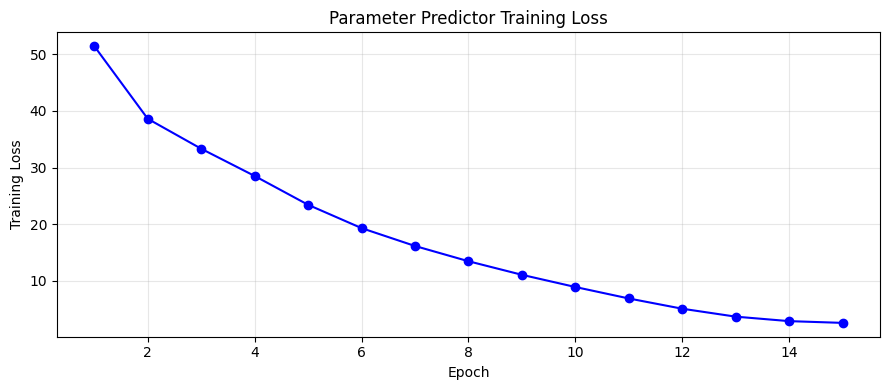

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, N_EPOCHS+1), train_losses, 'b-o', markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Parameter Predictor Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_loss.png'), dpi=150)
plt.show()

## Evaluate on LFW

In [ ]:
def cal_accuracy(y_score, y_true):
    y_score, y_true = np.asarray(y_score), np.asarray(y_true)
    best_acc, best_th = 0, 0
    for th in y_score:
        acc = np.mean(((y_score >= th) == y_true).astype(int))
        if acc > best_acc:
            best_acc, best_th = acc, th
    return best_acc, best_th


def run_eval(model_name, feat_model):
    print(f'\nEvaluating {model_name}...')
    predictor.eval()
    loader = DataLoader(
        LFW(LFW_ROOT, start=N_REF, end=N_REF + N_EVAL),
        batch_size=16, shuffle=False, num_workers=2
    )
    labels, sims = [], []
    with torch.no_grad():
        pbar = tqdm(loader, desc=model_name, bar_format='{l_bar}{bar:25}{r_bar}')
        for blob in pbar:
            for k in ('im1', 'im2'):
                blob[k] = blob[k].to(device)
            b       = blob['im1'].shape[0]
            im1     = blob['im1'] * 2 - 1
            im2     = blob['im2'] * 2 - 1
            params  = predictor(im1)
            opt     = apply_forbes_transforms(im1, params)
            feat, _ = feat_model(torch.cat((opt, im2), dim=0))
            sim = torch.bmm(
                feat[:b].unsqueeze(1),
                feat[b:].unsqueeze(2)
            ).squeeze(1).squeeze(1)
            sims.extend(sim.cpu())
            labels.extend(blob['tf'])
    acc, th = cal_accuracy(sims, labels)
    print(f'  {model_name} — Accuracy: {acc:.4f} ({acc*100:.2f}%)  Threshold: {th:.4f}')
    return acc


results_retrained = {}
for name, model in feature_models.items():
    results_retrained[name] = run_eval(name, model)

print('\n')
print('=' * 45)
print('  RETRAINED MODEL — LFW RESULTS')
print('=' * 45)
for name, acc in results_retrained.items():
    print(f'  {name:<10}  {acc*100:.2f}%')
print('=' * 45)


Evaluating AdaFace...


AdaFace: 100%|█████████████████████████| 157/157 [00:02<00:00, 59.44it/s]


  AdaFace — Accuracy: 0.5656 (56.56%)  Threshold: 0.0328

Evaluating MagFace...


MagFace: 100%|█████████████████████████| 157/157 [00:02<00:00, 60.01it/s]


  MagFace — Accuracy: 0.5992 (59.92%)  Threshold: 0.9158

Evaluating FaceNet...


FaceNet: 100%|█████████████████████████| 157/157 [00:01<00:00, 115.09it/s]


  FaceNet — Accuracy: 0.5384 (53.84%)  Threshold: 0.1010

Evaluating ArcFace...


ArcFace: 100%|█████████████████████████| 157/157 [00:11<00:00, 13.53it/s]

  ArcFace — Accuracy: 0.5764 (57.64%)  Threshold: 0.0330


  RETRAINED MODEL — LFW RESULTS
  AdaFace     56.56%
  MagFace     59.92%
  FaceNet     53.84%
  ArcFace     57.64%


## Before vs After Comparison Plot

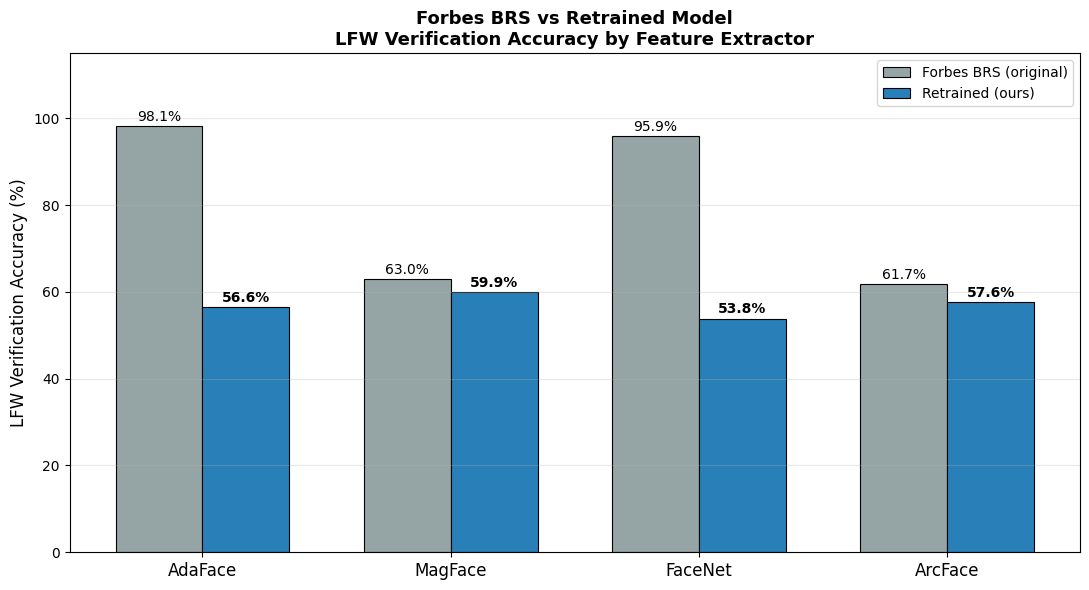

Saved: /content/output/retrained_comparison.png


In [ ]:
results_original = {
    'AdaFace': 0.9810,
    'MagFace': 0.6300,
    'FaceNet': 0.9590,
    'ArcFace': 0.6170
}

names  = list(results_retrained.keys())
before = [results_original[n] * 100 for n in names]
after  = [results_retrained[n] * 100 for n in names]
x      = np.arange(len(names))
width  = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, before, width, label='Forbes BRS (original)',
               color='#95a5a6', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, after,  width, label='Retrained (ours)',
               color='#2980b9', edgecolor='black', linewidth=0.8)

for bar, val in zip(bars1, before):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
for bar, val in zip(bars2, after):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0, 115)
ax.set_ylabel('LFW Verification Accuracy (%)', fontsize=12)
ax.set_title('Forbes BRS vs Retrained Model\nLFW Verification Accuracy by Feature Extractor',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'retrained_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')